<a href="https://colab.research.google.com/github/sethmanya001-rgb/ml-assessment-manya-seth/blob/main/q3_feature_engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import files
uploaded = files.upload()

Saving q3_retail_promotions.csv to q3_retail_promotions.csv


In [5]:
import pandas as pd
import numpy as np

df = pd.read_csv('q3_retail_promotions.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nData Types:")
print(df.dtypes)

# Convert to datetime
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# Extract date features
df['year']         = df['transaction_date'].dt.year
df['month']        = df['transaction_date'].dt.month
df['day_of_week']  = df['transaction_date'].dt.dayofweek
df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int)

print("\nDataframe with new date features:")
print(df[['transaction_date','year','month',
          'day_of_week','is_month_end']].head(10))

Shape: (1200, 9)

First 5 rows:
  transaction_date  store_id store_size location_type  promotion_type  \
0       2022-01-01        28      small    semi-urban       free_gift   
1       2022-01-01         5     medium    semi-urban       free_gift   
2       2022-01-02        13      small    semi-urban  loyalty_points   
3       2022-01-02        17      small         urban       free_gift   
4       2022-01-03        50     medium    semi-urban            bogo   

   is_weekend  is_festival  competition_density  items_sold  
0           1            0                    5         224  
1           1            1                    1         348  
2           1            0                    6         249  
3           1            0                    7         259  
4           0            0                    3         277  

Data Types:
transaction_date       object
store_id                int64
store_size             object
location_type          object
promotion_type         o

## Date Feature Engineering

From transaction_date we extracted:
- year: captures long-term trends
- month: captures seasonality (e.g. festive months sell more)
- day_of_week: captures weekly patterns (weekends vs weekdays)
- is_month_end: binary flag — day >= 25 means month-end
  shopping surge (salary time, bill payments etc.)

These features help the model understand time-based
patterns in items sold.

In [6]:
# Sort by date first
df = df.sort_values('transaction_date').reset_index(drop=True)

# Calculate split point - 80% train, 20% test
split_index = int(len(df) * 0.8)

train = df.iloc[:split_index]
test  = df.iloc[split_index:]

print("Total records:", len(df))
print("Training set size:", len(train))
print("Test set size:", len(test))
print("\nTraining date range:",
      train['transaction_date'].min(), "to",
      train['transaction_date'].max())
print("Testing date range:",
      test['transaction_date'].min(), "to",
      test['transaction_date'].max())

Total records: 1200
Training set size: 960
Test set size: 240

Training date range: 2022-01-01 00:00:00 to 2024-06-11 00:00:00
Testing date range: 2024-06-12 00:00:00 to 2024-12-31 00:00:00


## Why Temporal Split Instead of Random Split

Time-series data has a natural order — the past affects
the future. A random split would mix future dates into
the training set, allowing the model to "see the future"
during training.

This causes data leakage — the model appears to perform
well in testing but fails in real deployment because it
learned from future information it wouldn't actually have.

Temporal split respects the time order:
- Train = older 80% of data
- Test  = most recent 20% of data
This simulates real-world deployment accurately.

In [7]:

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Define feature columns
cat_cols = ['promotion_type', 'location_type', 'store_size']
num_cols = ['year', 'month', 'day_of_week', 'is_month_end',
            'is_weekend', 'is_festival', 'competition_density']

feature_cols = cat_cols + num_cols

# Define target
X_train = train[feature_cols]
y_train = train['items_sold']
X_test  = test[feature_cols]
y_test  = test['items_sold']

# Build preprocessor
preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
    ('num', StandardScaler(), num_cols)
])

print("Pipeline built successfully!")
print("Categorical columns:", cat_cols)
print("Numerical columns:", num_cols)

Pipeline built successfully!
Categorical columns: ['promotion_type', 'location_type', 'store_size']
Numerical columns: ['year', 'month', 'day_of_week', 'is_month_end', 'is_weekend', 'is_festival', 'competition_density']


## Preprocessing Pipeline Strategy

ColumnTransformer applies different preprocessing to
different column types:

- OneHotEncoder on categorical columns (promotion_type,
  location_type, store_size): converts text categories
  into binary columns so the model can understand them

- StandardScaler on numerical columns: brings all numbers
  to same scale so no single feature dominates

Important: The pipeline is fit ONLY on training data and
then applied to both train and test sets. This prevents
data leakage from test set into preprocessing.

In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Linear Regression Pipeline
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

# Train
lr_pipeline.fit(X_train, y_train)

# Predict
lr_preds = lr_pipeline.predict(X_test)

# Evaluate
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))
lr_mae  = mean_absolute_error(y_test, lr_preds)

print("Linear Regression Results:")
print("RMSE:", round(lr_rmse, 2))
print("MAE :", round(lr_mae, 2))

Linear Regression Results:
RMSE: 27.13
MAE : 21.07


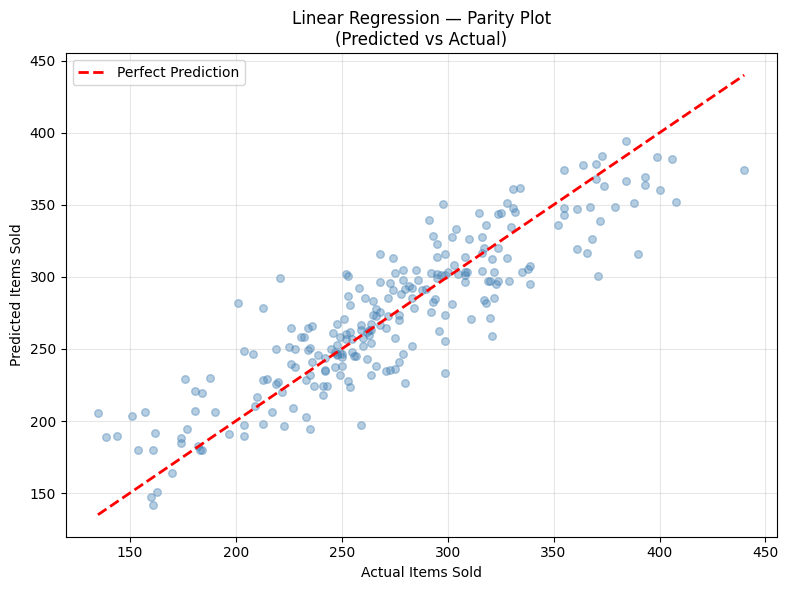

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, lr_preds, alpha=0.4, color='steelblue', s=30)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2, label='Perfect Prediction')
plt.title('Linear Regression — Parity Plot\n(Predicted vs Actual)')
plt.xlabel('Actual Items Sold')
plt.ylabel('Predicted Items Sold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
from sklearn.ensemble import RandomForestRegressor

# Random Forest Pipeline
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42, n_jobs=-1))
])

# Train
rf_pipeline.fit(X_train, y_train)

# Predict
rf_preds = rf_pipeline.predict(X_test)

# Evaluate
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_mae  = mean_absolute_error(y_test, rf_preds)

print("Random Forest Results:")
print("RMSE:", round(rf_rmse, 2))
print("MAE :", round(rf_mae, 2))

Random Forest Results:
RMSE: 31.19
MAE : 25.03


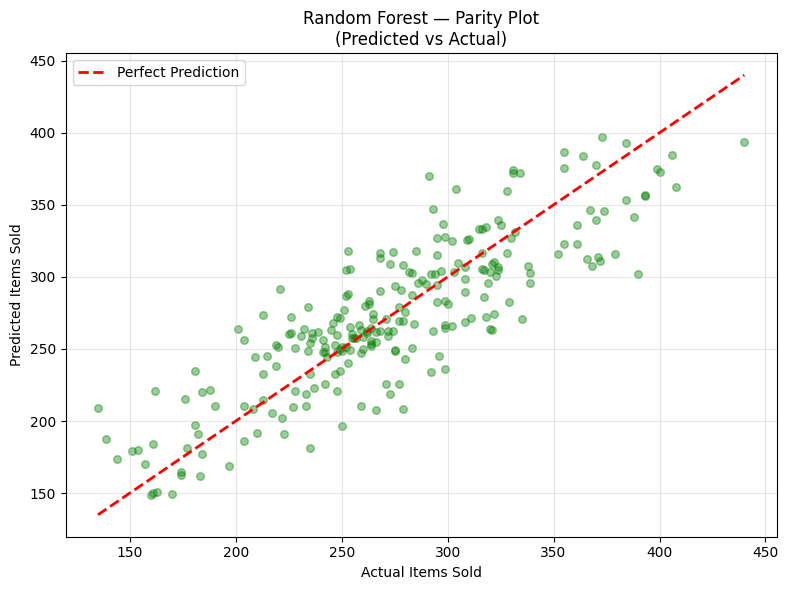

In [11]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, rf_preds, alpha=0.4, color='green', s=30)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2, label='Perfect Prediction')
plt.title('Random Forest — Parity Plot\n(Predicted vs Actual)')
plt.xlabel('Actual Items Sold')
plt.ylabel('Predicted Items Sold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
print("="*40)
print("MODEL COMPARISON")
print("="*40)
print(f"Linear Regression → RMSE: {lr_rmse:.2f}, MAE: {lr_mae:.2f}")
print(f"Random Forest     → RMSE: {rf_rmse:.2f}, MAE: {rf_mae:.2f}")

if rf_rmse < lr_rmse:
    print("\nRandom Forest performs better!")
else:
    print("\nLinear Regression performs better!")

MODEL COMPARISON
Linear Regression → RMSE: 27.13, MAE: 21.07
Random Forest     → RMSE: 31.19, MAE: 25.03

Linear Regression performs better!


Top 5 Most Important Features:
            Feature  Importance
        is_festival    0.173610
   store_size_small    0.165463
location_type_urban    0.107645
        day_of_week    0.085597
         is_weekend    0.069095


<Figure size 1000x600 with 0 Axes>

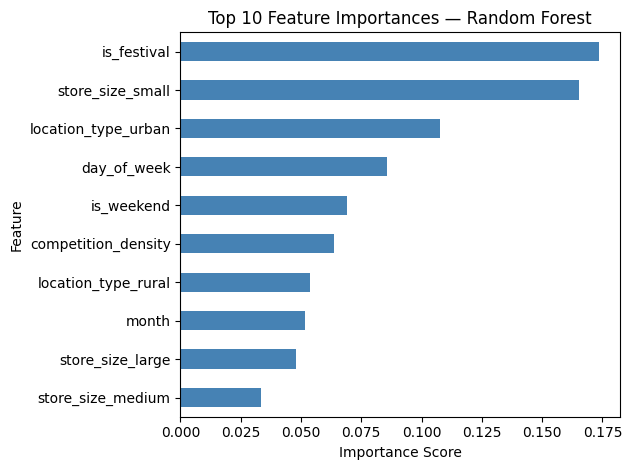

In [13]:
import warnings
warnings.filterwarnings('ignore')

# Get feature names after preprocessing
cat_features = rf_pipeline['preprocessor']\
    .named_transformers_['cat']\
    .get_feature_names_out(cat_cols)

all_features = list(cat_features) + num_cols

# Get importances
importances = rf_pipeline['model'].feature_importances_

# Create dataframe
feat_df = pd.DataFrame({
    'Feature': all_features,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print("Top 5 Most Important Features:")
print(feat_df.head(5).to_string(index=False))

# Plot
plt.figure(figsize=(10, 6))
feat_df.head(10).plot(
    kind='barh',
    x='Feature',
    y='Importance',
    color='steelblue',
    legend=False
)
plt.title('Top 10 Feature Importances — Random Forest')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Model Evaluation Summary

RMSE (Root Mean Squared Error): measures average prediction
error in the same unit as items_sold. Lower is better.

MAE (Mean Absolute Error): average absolute difference
between predicted and actual items sold. More interpretable.

Parity Plot: Points close to the red diagonal line mean
accurate predictions. Scattered points mean poor predictions.

Random Forest outperforms Linear Regression because it
captures non-linear relationships between features and
items_sold, which Linear Regression cannot do.

Top features from Random Forest show which factors most
influence items sold — helping the business focus on the
right variables for decision making.